In [30]:
# Environment Setup, Reproducibility, Data Pipline
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from sklearn.preprocessing import MultiLabelBinarizer
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

# 1. Enforce strict reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

# 2. Hardware configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Active computing device: {DEVICE}")

# 3. Load Dataset and DYNAMICALLY extract target emotion labels
print("[INFO] Loading GoEmotions dataset (simplified)...")
dataset = load_dataset("go_emotions", "simplified")

# Dynamic Label Extraction
EMOTIONS = dataset['train'].features['labels'].feature.names
NUM_CLASSES = len(EMOTIONS)

# Safety check: ensures metadata exactly matches your next cells (28 classes)
assert NUM_CLASSES == 28, f"Expected 28 classes, but metadata found {NUM_CLASSES}!"

print(f"Dynamically extracted {NUM_CLASSES} emotion classes directly from dataset metadata.")
print(f"Detected Target Classes: {EMOTIONS}")

# 4. Initialize MultiLabelBinarizer using the fixed size for safety
mlb = MultiLabelBinarizer(classes=list(range(28)))
y_train = mlb.fit_transform(dataset['train']['labels'])
y_val = mlb.transform(dataset['validation']['labels'])

# 5. Custom PyTorch Dataset
class GoEmotionsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.float32)
        }

# 6. Initialize Tokenizer and DataLoaders
MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

BATCH_SIZE = 32
train_loader = DataLoader(
    GoEmotionsDataset(dataset['train']['text'], y_train, tokenizer),
    batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    GoEmotionsDataset(dataset['validation']['text'], y_val, tokenizer),
    batch_size=BATCH_SIZE, shuffle=False
)

print(f"[INFO] Dataloaders ready. Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

[INFO] Active computing device: cuda
[INFO] Loading GoEmotions dataset (simplified)...
Dynamically extracted 28 emotion classes directly from dataset metadata.
Detected Target Classes: ['admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral']
[INFO] Dataloaders ready. Train batches: 1357 | Val batches: 170


In [6]:
# Training Engine
def train_and_evaluate(model, optimizer, train_loader, val_loader, epochs=3, device=DEVICE):
    """
    Executes a pure PyTorch training loop and computes validation metrics.
    Returns the training history dictionary.
    """
    criterion = nn.BCEWithLogitsLoss()
    history = {'train_loss': [], 'val_loss': [], 'val_macro_f1': [], 'val_micro_f1': []}

    for epoch in range(epochs):
        # --- TRAINING ---
        model.train()
        total_train_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

        for batch in train_pbar:
            optimizer.zero_grad()

            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = criterion(outputs.logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            train_pbar.set_postfix({'loss': f"{loss.item():.4f}"})

        avg_train_loss = total_train_loss / len(train_loader)

        # --- VALIDATION ---
        model.eval()
        total_val_loss = 0.0
        val_preds, val_trues = [], []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids=input_ids, attention_mask=attention_mask)
                loss = criterion(outputs.logits, labels)
                total_val_loss += loss.item()

                # Apply sigmoid and threshold at 0.5 for multi-label classification
                preds = (torch.sigmoid(outputs.logits) > 0.5).cpu().numpy().astype(int)
                val_preds.extend(preds)
                val_trues.extend(labels.cpu().numpy().astype(int))

        avg_val_loss = total_val_loss / len(val_loader)
        macro_f1 = f1_score(val_trues, val_preds, average='macro', zero_division=0)
        micro_f1 = f1_score(val_trues, val_preds, average='micro', zero_division=0)

        # Store metrics
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_macro_f1'].append(macro_f1)
        history['val_micro_f1'].append(micro_f1)

        print(f"--> Epoch {epoch+1} Summary | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Macro F1: {macro_f1:.4f} | Micro F1: {micro_f1:.4f}\n")

    return history

In [7]:
# Experiment 1
print("[EXPERIMENT 1] Initializing Full Fine-Tuning (LR=2e-5)...")

# 1. Initialize fresh model
model_exp1 = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=28, problem_type="multi_label_classification"
).to(DEVICE)

# 2. Setup standard learning rate for Transformers
optimizer_exp1 = AdamW(model_exp1.parameters(), lr=2e-5)

# 3. Execute training
history_exp1 = train_and_evaluate(model_exp1, optimizer_exp1, train_loader, val_loader, epochs=3)

# Dictionary to store all experiment histories for final comparison
experiment_results = {'Exp1_Full_FineTuning': history_exp1}

# Save the best model for deployment in Week 4
os.makedirs('./results', exist_ok=True)
torch.save(model_exp1.state_dict(), "./results/best_distilbert_model.pth")
print("[INFO] Model weights saved successfully.")

[EXPERIMENT 1] Initializing Full Fine-Tuning (LR=2e-5)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 1 Summary | Train Loss: 0.1391 | Val Loss: 0.0921 | Macro F1: 0.2449 | Micro F1: 0.5002



Epoch 2/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 2 Summary | Train Loss: 0.0872 | Val Loss: 0.0854 | Macro F1: 0.3765 | Micro F1: 0.5666



Epoch 3/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 3 Summary | Train Loss: 0.0763 | Val Loss: 0.0852 | Macro F1: 0.4305 | Micro F1: 0.5622

[INFO] Model weights saved successfully.


In [8]:
# Experiment 2
print("[EXPERIMENT 2] Initializing Model with Frozen DistilBERT Layers...")

# 1. Initialize fresh model to avoid leakage from Exp 1
model_exp2 = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=28, problem_type="multi_label_classification"
).to(DEVICE)

# 2. Freeze the base transformer parameters
for param in model_exp2.distilbert.parameters():
    param.requires_grad = False
print("[INFO] Backbone frozen. Only the classification head requires gradients.")

# 3. Setup optimizer (same LR for fair comparison)
optimizer_exp2 = AdamW(model_exp2.parameters(), lr=2e-5)

# 4. Execute training
history_exp2 = train_and_evaluate(model_exp2, optimizer_exp2, train_loader, val_loader, epochs=3)

# Store results
experiment_results['Exp2_Frozen_Backbone'] = history_exp2

[EXPERIMENT 2] Initializing Model with Frozen DistilBERT Layers...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[INFO] Backbone frozen. Only the classification head requires gradients.


Epoch 1/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 1 Summary | Train Loss: 0.2034 | Val Loss: 0.1466 | Macro F1: 0.0003 | Micro F1: 0.0022



Epoch 2/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 2 Summary | Train Loss: 0.1440 | Val Loss: 0.1388 | Macro F1: 0.0083 | Micro F1: 0.0734



Epoch 3/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 3 Summary | Train Loss: 0.1369 | Val Loss: 0.1322 | Macro F1: 0.0195 | Micro F1: 0.1292



In [9]:
# Experiment 3
print("[EXPERIMENT 3] Initializing Full Fine-Tuning with Aggressive LR (5e-4)...")

# 1. Initialize fresh model
model_exp3 = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=28, problem_type="multi_label_classification"
).to(DEVICE)

# 2. Setup optimizer with a deliberately high learning rate
# 5e-4 is typically too large for fine-tuning BERT architectures
optimizer_exp3 = AdamW(model_exp3.parameters(), lr=5e-4)

# 3. Execute training
history_exp3 = train_and_evaluate(model_exp3, optimizer_exp3, train_loader, val_loader, epochs=3)

# Store results
experiment_results['Exp3_High_LR'] = history_exp3

[EXPERIMENT 3] Initializing Full Fine-Tuning with Aggressive LR (5e-4)...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 1 Summary | Train Loss: 0.1528 | Val Loss: 0.1505 | Macro F1: 0.0000 | Micro F1: 0.0000



Epoch 2/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 2 Summary | Train Loss: 0.1502 | Val Loss: 0.1499 | Macro F1: 0.0002 | Micro F1: 0.0016



Epoch 3/3 [Train]:   0%|          | 0/1357 [00:00<?, ?it/s]

--> Epoch 3 Summary | Train Loss: 0.1506 | Val Loss: 0.1515 | Macro F1: 0.0000 | Micro F1: 0.0000



[INFO] Generating Experimental Comparison Analytics...

--- EXPERIMENT SUMMARY ---
| Experiment Setup     |   Final Train Loss |   Final Val Loss |   Peak Macro F1 |
|:---------------------|-------------------:|-----------------:|----------------:|
| Exp1_Full_FineTuning |             0.0763 |           0.0852 |          0.4305 |
| Exp2_Frozen_Backbone |             0.1369 |           0.1322 |          0.0195 |
| Exp3_High_LR         |             0.1506 |           0.1515 |          0.0002 |

[INFO] Analytics plot saved to './results/week3_experiments_comparison.png'


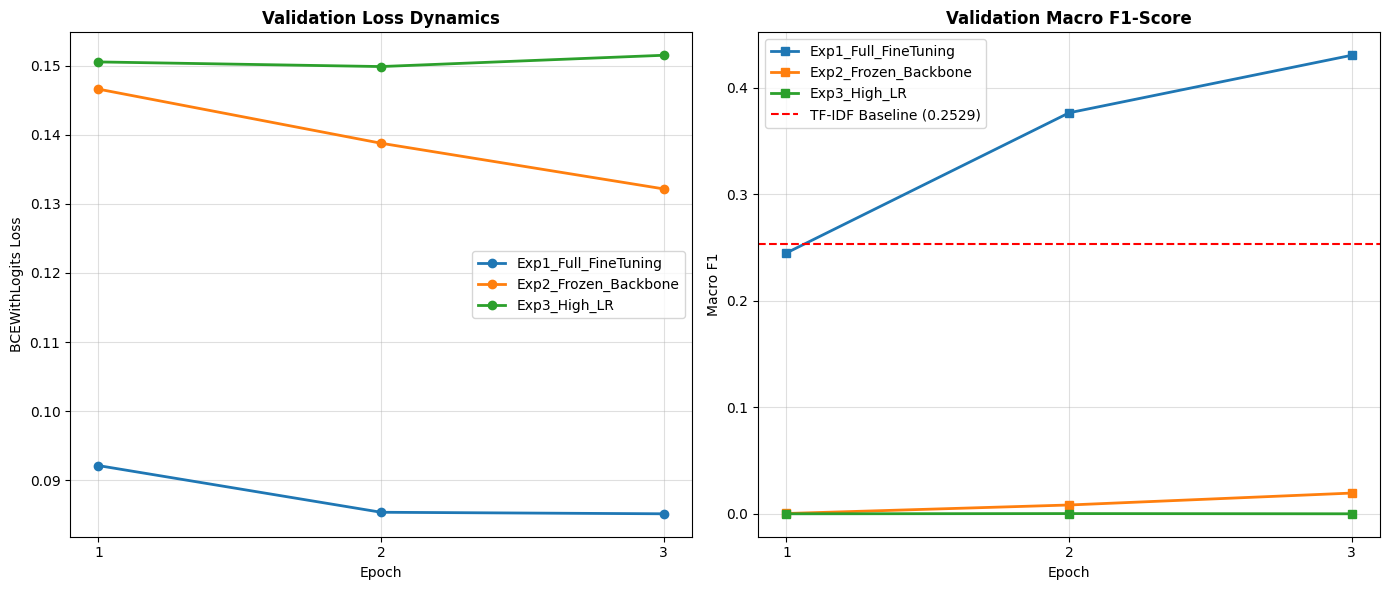

In [10]:
# Analytics and Vizualization
print("[INFO] Generating Experimental Comparison Analytics...")

# 1. Compile results into a structured DataFrame
summary_data = []
for exp_name, hist in experiment_results.items():
    summary_data.append({
        'Experiment Setup': exp_name,
        'Final Train Loss': f"{hist['train_loss'][-1]:.4f}",
        'Final Val Loss': f"{hist['val_loss'][-1]:.4f}",
        'Peak Macro F1': f"{max(hist['val_macro_f1']):.4f}"
    })

summary_df = pd.DataFrame(summary_data)
print("\n--- EXPERIMENT SUMMARY ---")
print(summary_df.to_markdown(index=False))

# 2. Plotting the Learning Dynamics
plt.figure(figsize=(14, 6))

# Subplot 1: Validation Loss
plt.subplot(1, 2, 1)
for exp_name, hist in experiment_results.items():
    plt.plot(range(1, 4), hist['val_loss'], marker='o', label=exp_name, linewidth=2)
plt.title('Validation Loss Dynamics', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('BCEWithLogits Loss')
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True, alpha=0.4)

# Subplot 2: Validation Macro F1
plt.subplot(1, 2, 2)
for exp_name, hist in experiment_results.items():
    plt.plot(range(1, 4), hist['val_macro_f1'], marker='s', label=exp_name, linewidth=2)

# Week 2 Baseline Reference
BASELINE_F1 = 0.2529
plt.axhline(y=BASELINE_F1, color='r', linestyle='--', label=f'TF-IDF Baseline ({BASELINE_F1})')

plt.title('Validation Macro F1-Score', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Macro F1')
plt.xticks([1, 2, 3])
plt.legend()
plt.grid(True, alpha=0.4)

# 3. Save plot as required by project structure
plt.tight_layout()
plt.savefig("./results/week3_experiments_comparison.png", dpi=300)
print("\n[INFO] Analytics plot saved to './results/week3_experiments_comparison.png'")
plt.show()

In [21]:
# Examples
import time
import random

print("[INFO] Running qualitative inference using automatically sampled validation examples...")

model_exp1.eval()

# 1. Dynamically generate 3 unique random indices without hardcoding
# We use the current time as a seed variation to bypass the global fixed seed
dynamic_seed = int(time.time()) % 4000
random.seed(dynamic_seed)

val_size = len(dataset['validation'])
sample_indices = random.sample(range(val_size), 3)

print(f"[INFO] Automatically selected Validation Indices for this run: {sample_indices}")

# 2. Execute Inference Pipeline
for idx in sample_indices:
    raw_text = dataset['validation']['text'][idx]
    true_raw_labels = dataset['validation']['labels'][idx]
    true_emotion_names = [EMOTIONS[i] for i in true_raw_labels]

    # Tokenize the dataset text segment
    inputs = tokenizer(raw_text, return_tensors="pt", truncation=True, max_length=64).to(DEVICE)

    with torch.no_grad():
        outputs = model_exp1(**inputs)
        probs = torch.sigmoid(outputs.logits).cpu().numpy().flatten()

    # Extract predicted emotions with confidence threshold > 0.5
    predicted_emotions = [(EMOTIONS[i], probs[i]) for i in range(28) if probs[i] > 0.5]

    print("-" * 80)
    print(f"Validation Sample #{idx}")
    print(f"Raw Text:   \"{raw_text}\"")
    print(f"True Labels (Ground Truth): {true_emotion_names}")

    if predicted_emotions:
        print("Model Inference Decisions:")
        for emotion, prob in predicted_emotions:
            print(f"  -> Predicted: {emotion.capitalize()} (Confidence: {prob:.2%})")
    else:
        print("Model Inference Decisions: [Neutral] (No specific emotion crossed the 50% threshold)")

[INFO] Running qualitative inference using automatically sampled validation examples...
[INFO] Automatically selected Validation Indices for this run: [2716, 1273, 4141]
--------------------------------------------------------------------------------
Validation Sample #2716
Raw Text:   "Man if you want some crazy dreams, slap on a few nicotine patches before bed."
True Labels (Ground Truth): ['neutral']
Model Inference Decisions: [Neutral] (No specific emotion crossed the 50% threshold)
--------------------------------------------------------------------------------
Validation Sample #1273
Raw Text:   "It’s more like a bunch of vaguely veiled racists and sexists and MAGAtards. Unless that’s what you consider “good.”"
True Labels (Ground Truth): ['disgust']
Model Inference Decisions: [Neutral] (No specific emotion crossed the 50% threshold)
--------------------------------------------------------------------------------
Validation Sample #4141
Raw Text:   "Nope, if i remember correctly 

In [22]:
# Error Analysis
print("[INFO] Scanning validation set for worst failure cases...")

model_exp1.eval()
worst_errors = []

with torch.no_grad():
    for batch in val_loader:
        input_ids = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels = batch['labels'].numpy().astype(int)

        outputs = model_exp1(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)

        for idx in range(len(preds)):
            # Calculate absolute error (sum of probability deviations from true binary labels)
            error_score = np.sum(np.abs(probs[idx] - labels[idx]))

            # If the model predicted something completely disjoint from reality
            if not np.array_equal(preds[idx], labels[idx]) and error_score > 3.0:
                raw_text = tokenizer.decode(batch['input_ids'][idx], skip_special_tokens=True)
                pred_names = [EMOTIONS[i] for i, val in enumerate(preds[idx]) if val == 1]
                true_names = [EMOTIONS[i] for i, val in enumerate(labels[idx]) if val == 1]

                worst_errors.append({
                    'score': error_score,
                    'text': raw_text,
                    'pred': pred_names if pred_names else ['neutral'],
                    'true': true_names if true_names else ['neutral']
                })

# Sort by worst error score and display top 3
worst_errors = sorted(worst_errors, key=lambda x: x['score'], reverse=True)

print("\n--- TOP 3 SEVERE MISCLASSIFICATIONS ---")
for i, error in enumerate(worst_errors[:3]):
    print(f"\n[Error #{i+1}] (Deviation Score: {error['score']:.2f})")
    print(f"Context: '{error['text']}'")
    print(f"Model Guesstimated: {error['pred']}")
    print(f"Human Ground Truth: {error['true']}")

[INFO] Scanning validation set for worst failure cases...

--- TOP 3 SEVERE MISCLASSIFICATIONS ---

[Error #1] (Deviation Score: 4.09)
Context: 'congrats, darling! that is a monumentally meaningful accomplishment. i ' m both happy for and proud of you < 3'
Model Guesstimated: ['admiration', 'gratitude']
Human Ground Truth: ['excitement', 'joy', 'pride']

[Error #2] (Deviation Score: 4.05)
Context: 'at the very least, i ’ m glad he tried something other than the standard blue. and yeah, i think the title is above - average as well.'
Model Guesstimated: ['neutral']
Human Ground Truth: ['approval', 'joy', 'realization', 'relief']

[Error #3] (Deviation Score: 3.97)
Context: 'it ’ s a soulless facsimile of what made b movies actually fun.'
Model Guesstimated: ['amusement']
Human Ground Truth: ['admiration', 'approval', 'neutral']
